## NLP Analysis of *Dear Hank & John* Podcast Transcripts

This notebook explores a series of Natural Language Processing (NLP) techniques using transcripts from the podcast *Dear Hank & John*. The workflow includes the following steps:

### 1. Web scraping
Collect transcripts for each episode by paginating through:  
https://podscripts.co/podcasts/dear-hank-john/

### 2. Text preprocessing
Clean and normalize each transcript by:
- Removing excess whitespace
- Identifying transcription errors
- Applying lemmatization
- Tokenizing the text

### 3. Sentiment analysis with VADER
Use the VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analyzer to score each sentence.
- Identify the top and bottom 20 episodes by average sentiment
- Visualize how sentiment changes over time across the series

### 4. Word Cloud generation
Create word clouds to highlight the most prominent topics discussed in the podcast.

### 5. TF‑IDF analysis
Compute TF‑IDF (Term Frequency–Inverse Document Frequency) scores to identify words and phrases that are uniquely characteristic of individual episodes.


---

In [1]:
import os
import re
import time
import json
import math
import random
from collections import defaultdict, Counter
from urllib.parse import urljoin
from datetime import datetime

import requests
from bs4 import BeautifulSoup
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
# File serving as a JSON data store
OUTPUT_FILE = "data/dear_hank_john_transcripts.json"

# Define website parameters to use for web scraping
DOMAIN = "https://podscripts.co"
EPISODE_PATH = "/podcasts/dear-hank-john"
BASE_URL = f"{DOMAIN}{EPISODE_PATH}"

# Regex used throughout the code
PREFIX_PATTERN = re.compile(r"^Dear Hank & John\s*-\s*")
TITLE_PATTERN = re.compile(r'^(?:[A-Za-z]+)?(\d+)(?:st|nd|rd|th)?[:\s-]*(.*)')
WHITESPACE_PATTERN = re.compile(r"\s+")

#### **Helper functions to save and load our data**

In [3]:
def save_data(data):
    """ Save latest version of JSON data store """
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

def load_existing_data():
    """ Load JSON data store from disk """
    if not os.path.exists(OUTPUT_FILE):
        return []

    with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
        return json.load(f)

#### **Web scraping functions**

In [4]:
def scrape_single_episode(url):
    """ Pull transcript for a single episode and save to a dictionary """

    # Fetch the current episode
    response = requests.get(url)
    
    # Throw an error if page is not found
    response.raise_for_status()

    # Parse the HTML response
    soup = BeautifulSoup(response.text, "html.parser")

    # Extract relevant fields
    heading_tag = soup.select_one("h1.page-heading")
    heading = heading_tag.get_text(strip=True) if heading_tag else "Unknown Heading"

    date_tag = soup.select_one("span.episode_date")
    episode_date = (
        date_tag.get_text(strip=True).replace("Episode Date: ", "")
        if date_tag else None
    )
    sentence_spans = soup.select("span.pod_text")

    if not sentence_spans:
        raise ValueError("NO TRANSCRIPT FOUND - Page structure may have changed")

    # Combine extracted text into separate lines
    transcript_text = "\n".join(
        span.get_text(strip=True)
        for span in sentence_spans
        if span.get_text(strip=True)
    )

    # Podcast Episode Dictionary:
    return {
        "title": heading,
        "url": url,
        "episode_date": episode_date,
        "transcript": transcript_text,
    }



In [5]:
def scrape_all_episodes():
    """ Loop through all episode URL links and apply web scraper """

    # Load all existing data
    all_episodes = load_existing_data()

    # Normalize URLs to avoid trailing slash mismatches
    seen_urls = {ep["url"].rstrip("/") for ep in all_episodes}

    print("------------------------------------------")
    print("LOOKING FOR DEAR HANK & JOHN EPISODES")
    print("------------------------------------------ \n")

    # Start at page 1 and continue pagination until no new episodes are found
    page_num = 1
    
    while True:
        print(f"Checking page {page_num}...")

        res = requests.get(f"{BASE_URL}?page={page_num}", timeout=10)

        # Exit the loop if the server fails to return a 200 response code
        if res.status_code != 200:
            print("** Server is not responding. Check url parameters **")
            break

        soup = BeautifulSoup(res.text, "html.parser")

        # Collect all episode links on this page
        page_links = []
        page_seen = set()

        for link in soup.find_all("a", href=True):
            # Normalize the URL:
            href = urljoin(DOMAIN, link["href"]).rstrip("/")

            # Check if the URL found is a podcast episode 
            if EPISODE_PATH + "/" in href and href != BASE_URL.rstrip("/"):

                # Avoid duplicates:
                if href not in seen_urls and href not in page_seen:
                    page_links.append(href)
                    page_seen.add(href)

        # If no new episode links were found, we've reached the end of the archive
        if not page_links:
            if page_num == 1:
                print("\t No new episodes found")
            else:
                print("\t All new episodes have been saved. Exiting...")
            break

        # Scrape each episode found on this page
        for url in page_links:
            print(f"\t EPISODE: {url}")

            try:
                ep_data = scrape_single_episode(url)

                # Save progress and mark URL as complete
                all_episodes.append(ep_data)
                save_data(all_episodes)
                seen_urls.add(url)

                # Spread out requests to avoid rate-limiting
                time.sleep(random.uniform(5, 15))

            except Exception as e:
                print(f"\t ERROR: {e}")

        # Move to the next archive page
        page_num += 1
    
    print("\n------------------------------------------")
    print("DONE")
    print("------------------------------------------ \n")


#### **Miscellaneous helper functions**

In [6]:
def sort_by_episode_date(episodes):
    return sorted(
        episodes,
        key=lambda ep: datetime.strptime(ep["episode_date"], "%B %d, %Y")
    )

In [7]:
def parse_title(title):
    """Parse episode title to and extract episode number """
    title_clean = PREFIX_PATTERN.sub("", title)
    
    match = TITLE_PATTERN.match(title_clean)
    if match:
        return int(match.group(1)), match.group(2).strip()

    return None, title_clean.strip()

---

### **Finish pre-processing our episodes dictionary**

In [8]:
# Scrape all (newly found) episodes
scrape_all_episodes()

------------------------------------------
LOOKING FOR DEAR HANK & JOHN EPISODES
------------------------------------------ 

Checking page 1...
	 No new episodes found

------------------------------------------
DONE
------------------------------------------ 



In [9]:
# Load saved episodes and sort by release date
episodes = load_existing_data()
episodes = sort_by_episode_date(episodes)

In [10]:
for ep in episodes:

    # Transcription error found in many episodes --> clearly meant to say “hank and John”
    ep["transcript"] = re.sub(r"hankajun|hankajan", "hank and john", ep["transcript"], flags=re.IGNORECASE)
    
    
    # Extract the episode number and the remaining title text.
    ep["episode_number"], ep["title_text"] = parse_title(ep["title"])

    # Convert episode_date into a datetime object.
    ep["episode_date"] = pd.to_datetime(ep["episode_date"], format="%B %d, %Y")


In [11]:
# Easy retrieval of podcast by episode number
episode_lookup = {ep["episode_number"]: ep for ep in episodes}

---

### **Text Preprocessing for NLP Analysis**

In [12]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download('vader_lexicon', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True);

In [13]:
def clean_text(t):
    """ Remove whitespace and extraneous line breaks """
    t = t.replace("\n", " ")
    t = WHITESPACE_PATTERN.sub(" ", t).strip()
    return t


In [14]:
# ---------------------------------------------------------
# Lemmatization utilities
# ---------------------------------------------------------

# Initialize a WordNet lemmatizer
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """ Convert NLTK  tags to WordNet tags to get correct part of speech (POS)"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN


def lemmatize_token(word, pos_tag):
    """ Lemmatize a single token using its POS tag """
    wn_pos = get_wordnet_pos(pos_tag)
    return lemmatizer.lemmatize(word, wn_pos)


def lemmatize_sentence(sentence):
    """
    Lemmatize an entire sentence using POS-aware lemmatization.
    This is needed so that differing POS are treated differently.

    Steps:
      1. Split the sentence into tokens
      2. POS-tag each token using NLTK
      3. Convert POS tags to WordNet format
      4. Lemmatize each token with its POS
      5. Rejoin the tokens
    """

    # Step 1
    tokens = sentence.split()

    # Step 2
    pos_tags = nltk.pos_tag(tokens)

    # Step 3 & 4
    lemmas = [
        lemmatize_token(word, pos)
        for word, pos in pos_tags
    ]

    # Step 5
    return " ".join(lemmas)


In [15]:
# ---------------------------------------------------------
# Some transcripts contain a recurring error where a phrase or even a full sentence is duplicated many times
# The following functions attempt to remove those repeated fragments so the text reflects what was actually said
# ---------------------------------------------------------
def dedupe_sentences(sentences, max_repeats=1):
    """ Remove repeated full sentences """
    # Tracks sentence counts
    seen = defaultdict(int)
    cleaned = []
    
    for s in sentences:
        norm = s.strip().lower()
        
        # Keep the sentence only if it hasn't exceeded allowed repeats
        if seen[norm] < max_repeats:
            cleaned.append(s)
            seen[norm] += 1

    return cleaned


In [16]:
def remove_repeated_ngrams(sentence, max_repeats=1):
    """
    Remove repeated unigrams, bigrams, and trigrams from a sentence """

    # Normalize punctuation for matching
    normalized = re.sub(r"[^\w\s']", " ", sentence)
    tokens = normalized.split()

    # Tracks how many times each n-gram has appeared
    seen = {}
    cleaned = []
    i = 0

    # Process an n-gram of size n starting at index i
    def process_ngram(n):
        """
        This helper takes care of:
          - building the n-gram
          - repeated-token removal
          - max_repeats enforcement

        Returns:
            (gram, step)
            - gram: tuple of tokens to keep, or None if skipped
            - step: how many tokens to advance (always n)
        
        """
        
        gram = tuple(tokens[i:i+n])

        # Special case: remove repeated-word bigrams/trigrams
        if n > 1 and len(set(gram)) == 1:
            return None, n

        # Standard repeat check: keep only if under max_repeats
        if seen.get(gram, 0) < max_repeats:
            seen[gram] = seen.get(gram, 0) + 1
            return gram, n

        # Otherwise skip, but still advance n tokens
        return None, n

    # ---------------------------------------------------------
    # Remove n‑grams in descending order: trigrams → bigrams → unigrams
    # ---------------------------------------------------------
    while i < len(tokens):

        # Trigrams
        if i + 2 < len(tokens):
            gram, step = process_ngram(3)
            if gram:
                cleaned.extend(gram)
            i += step
            continue

        # Bigrams
        if i + 1 < len(tokens):
            gram, step = process_ngram(2)
            if gram:
                cleaned.extend(gram)
            i += step
            continue

        # Unigrams
        gram, step = process_ngram(1)
        if gram:
            cleaned.extend(gram)
        i += step

    # Join tokens back into a sentence
    return " ".join(cleaned)


---

### **Sentiment Analysis**

We use VADER (Valence Aware Dictionary and sEntiment Reasoner) for sentiment analysis because it is optimized for informal, conversational language, making it a strong fit for podcast transcripts.

In [17]:
sia = SentimentIntensityAnalyzer() # VADER

def episode_sentiment(text):
    """ Compute average VADER sentiment for podcast episode """

    # 1) Basic text normalization
    text = clean_text(text)

    # 2) Sentence tokenization
    sentences = nltk.sent_tokenize(text)

    # 3) Remove repeated sentences (transcript glitches)
    sentences = dedupe_sentences(sentences, max_repeats=2)

    # 4) Remove repeated n-grams inside each sentence (transcript glitches)
    sentences = [remove_repeated_ngrams(s, max_repeats=1) for s in sentences]

    # 5) Lemmatize each sentence
    sentences = [lemmatize_sentence(s) for s in sentences]

    # 6) Sentiment scoring (VADER compound score per sentence)
    sentence_scores = [
        (sia.polarity_scores(s)['compound'], len(s.split()))
        for s in sentences
    ]
    
    # 7) Log-scaled weighting: longer sentences get more weight, but never dominate
    weighted_scores = [
        (score, math.log1p(length))
        for score, length in sentence_scores
    ]

    total_weight = sum(w for _, w in weighted_scores)
    weighted_sum = sum(score * w for score, w in weighted_scores)

    return weighted_sum / total_weight


In [18]:
# Score each episode
for ep in tqdm(episodes, desc = 'Scoring episodes'):
    ep['overall_sentiment'] = episode_sentiment(ep['transcript'])

Scoring episodes: 100%|███████████████████████| 444/444 [02:02<00:00,  3.64it/s]


In [19]:
# Convert to a pandas DataFrame
df_episodes = pd.DataFrame(episodes)

# Convert episode_number to nullable integer (a few episodes have no episode_number)
df_episodes['episode_number'] = df_episodes['episode_number'].astype('Int64')

VADER sentiment scores range from -1 to 1, going from very negative to very positive, respectively. We compute these scores at the sentence level for each episode. One limitation to the analysis is that the hosts can often use sarcasm and “dark humor”, which can be difficult to detect from text alone. However, the podcast is generally light-hearted in nature. 

First, we examine the top and bottom 20 podcast episodes based on their average sentence‑level sentiment. 

Next, we turn to a heat map that visualizes how average sentiment shifts over time across the full podcast series.

In [20]:
# ---------------------------------------------------------
# Top 20 Podcasts by Overall Sentiment
# ---------------------------------------------------------
sentiment_top20 = (
    df_episodes
    .sort_values(by='overall_sentiment', ascending=False)
    .head(20)
)

cols = ['episode_number', 'title_text', 'overall_sentiment', 'episode_date']

sentiment_top20 = sentiment_top20[cols].rename(columns={
    'episode_number': 'Episode #',
    'title_text': 'Title',
    'overall_sentiment': 'Episode Sentiment Score',
    'episode_date': 'Episode Date'
})

styled_top20 = (
    sentiment_top20
    .style
    .hide(axis="index")
    .map(lambda _: "font-weight: bold", subset=['Episode #', 'Title', 'Episode Sentiment Score'])
    .set_properties(subset=['Episode #'], **{'text-align': 'center'})
    .set_properties(subset=['Title'], **{'text-align': 'left'})
    .set_properties(subset=['Episode Sentiment Score'], **{'text-align': 'center'})
    .set_properties(subset=['Episode Date'], **{'text-align': 'center'})
    .set_table_styles([
        {"selector": "th.col_heading", "props": [("text-align", "center")]}
    ])
    .format({
        'Episode Date': lambda d: d.strftime("%Y-%m-%d"),
        'Episode Sentiment Score': '{:.3f}'.format
    })
    .background_gradient(subset=['Episode Sentiment Score'], cmap='Greens')
)

styled_top20


Episode #,Title,Episode Sentiment Score,Episode Date
221,Favorites of the 2010s,0.323,2020-01-06
248,Nature's Solar Panels,0.307,2020-07-13
71,Only Pause for Applause (w/ Hannah Hart!),0.284,2016-12-06
377,Dear Hank and John: Taylor's Version,0.282,2023-11-29
27,Giving Gifts without Breaking the Bank,0.282,2015-12-07
8,Dear Hank and Grace (w/ Grace Helbig!),0.282,2015-07-27
103,There Are No Boxes (w/ Gaby Dunn!),0.279,2017-08-14
157,It's My Soundtrack! (w/ Rosianna Halse Rojas!),0.269,2018-10-01
228,"You Say Banana, I Say Banana (w/ Rosianna Halse Rojas!)",0.266,2020-02-24
287,The AFC Wimbledon & Mars Spectacular,0.264,2021-04-26


In [21]:
# ---------------------------------------------------------
# Bottom 20 Podcasts by Overall Sentiment
# ---------------------------------------------------------

sentiment_bottom20 = (
    df_episodes
    .sort_values(by='overall_sentiment', ascending=True)
    .head(20)
)

cols = ['episode_number', 'title_text', 'overall_sentiment', 'episode_date']

sentiment_bottom20 = sentiment_bottom20[cols].rename(columns={
    'episode_number': 'Episode #',
    'title_text': 'Title',
    'overall_sentiment': 'Episode Sentiment Score',
    'episode_date': 'Episode Date'
})

styled_bottom20 = (
    sentiment_bottom20
    .style
    .hide(axis="index")
    .map(lambda _: "font-weight: bold", subset=['Episode #', 'Title', 'Episode Sentiment Score'])
    .set_properties(subset=['Episode #'], **{'text-align': 'center'})
    .set_properties(subset=['Title'], **{'text-align': 'left'})
    .set_properties(subset=['Episode Sentiment Score'], **{'text-align': 'center'})
    .set_properties(subset=['Episode Date'], **{'text-align': 'center'})
    .set_table_styles([
        {"selector": "th.col_heading", "props": [("text-align", "center")]}
    ])
    .format({
        'Episode Date': lambda d: d.strftime("%Y-%m-%d"),
        'Episode Sentiment Score': '{:.3f}'.format
    })
    .background_gradient(subset=['Episode Sentiment Score'], cmap='Reds_r')
)

styled_bottom20


Episode #,Title,Episode Sentiment Score,Episode Date
408,The Green Brothers Often Are Wrong,0.108,2025-03-05
407,Concepts of a Bubble,0.110,2025-02-19
404,Die on Tuesday,0.110,2025-01-08
430,A Yawn Across Time,0.118,2025-10-29
52,We Are in This Together,0.119,2016-06-21
326,"The Best of Dear Hank and John, Vol. 3",0.121,2022-04-04
218,Hank & John's Airport Stories,0.126,2019-12-09
212,The Billionaire Cactus Ghost,0.127,2019-10-28
302,"Please, Your Reimbursement Here",0.128,2021-08-30
439,Division I Saint,0.128,2026-01-28


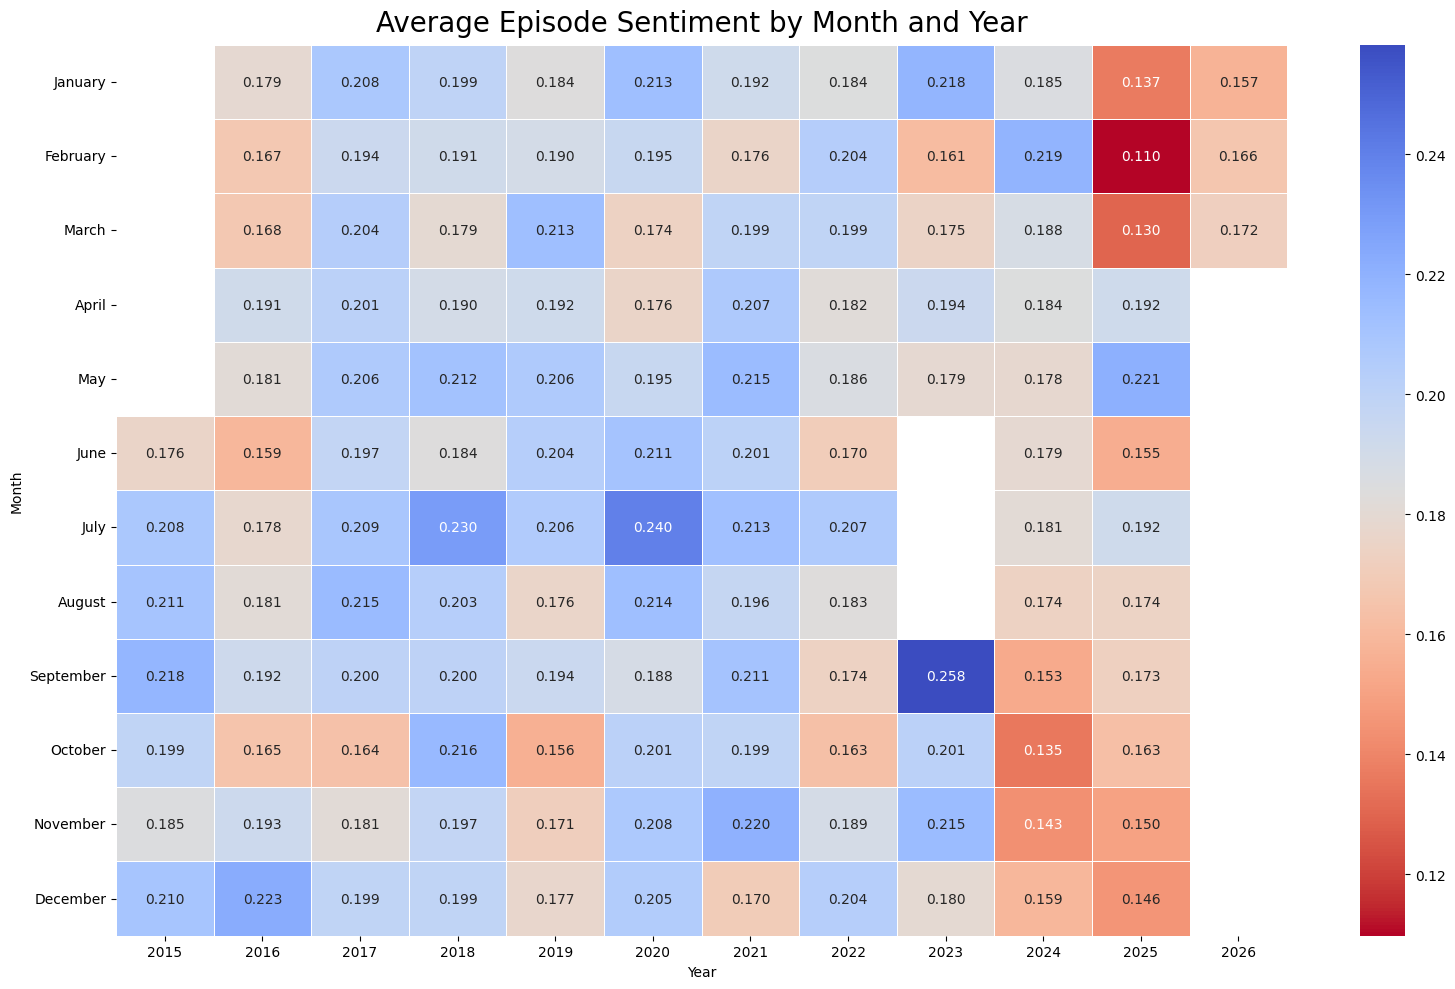

In [22]:
# ---------------------------------------------------------
# Heatmap visualization of sentiment scores across year–month combinations
# ---------------------------------------------------------

df_episodes['year'] = df_episodes['episode_date'].dt.year
df_episodes['month'] = df_episodes['episode_date'].dt.month

MONTH_ORDER = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df_episodes['month_name'] = pd.Categorical(
    df_episodes['episode_date'].dt.strftime('%B'),
    categories=MONTH_ORDER,
    ordered=True
)

heatmap_data = df_episodes.pivot_table(
    index='month_name',
    columns='year',
    values='overall_sentiment',
    aggfunc='mean',
    observed=False
)

plt.figure(figsize=(16, 10))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm_r',
    annot=True,
    fmt=".3f",
    linewidths=.5
)

plt.title("Average Episode Sentiment by Month and Year", fontsize=20, pad=10)
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()
plt.show()


---

### **Word Cloud Charts**

In [23]:
def preprocess_for_wordcloud(text):
    """ Text preprocessing needed for word‑cloud generation """

    # 1) Basic text normalization
    text = clean_text(text).lower()

    # 2) Sentence tokenization
    sentences = nltk.sent_tokenize(text)

    # 3) Remove repeated sentences (transcript glitches)
    sentences = dedupe_sentences(sentences, max_repeats=2)

    # 4) Remove repeated n-grams inside each sentence (transcript glitches)
    cleaned = [remove_repeated_ngrams(s, max_repeats=1) for s in sentences]

    # 5) Lemmatize each sentence
    lemmatized = [lemmatize_sentence(s) for s in cleaned]

    # 6) Drop 1‑character noise (e.g. punctuation)
    final_tokens = [t for t in " ".join(lemmatized).split() if len(t) > 1]

    # 7) Return a single clean string for word‑cloud generation
    return " ".join(final_tokens)


In [24]:
def generate_wordcloud(processed_text, stopwords,
                       colormap="mako", random_state=42, title=None):
    """Generate and display a word cloud from a preprocessed transcript text """

    title_color = "#0A3B5C" # Dark Teal
    
    wc = WordCloud(
        width=1600,
        height=800,
        background_color="white",
        stopwords=stopwords,
        colormap=colormap,
        random_state=random_state
    ).generate(processed_text)

    plt.figure(figsize=(16, 10))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    if title:
        plt.title(title, fontsize=20, pad=20, color=title_color)
    plt.show()

    return wc


#### **Generate a word cloud chart for all podcast episodes available**

In [25]:
# ---------------------------------------------------------
# Generate a word cloud for all podcast episodes available 
# Also generate our set of stop words
# ---------------------------------------------------------

all_text = " ".join(preprocess_for_wordcloud(ep["transcript"]) for ep in episodes)

tokens = all_text.split()

# Generate set of stop words, and add 100 most common words to this set
word_counts = Counter(tokens)
common_words = word_counts.most_common(100)
top_100 = set(word for word, _ in common_words)

stopwords = set(STOPWORDS)

# Extra stop words that should be added
extra_stopwords = {
    '[♪', 'ha', 'um', 'uh', 'like'
}

# Any known ads which could have an outsized impact
ad_stopwords = {
    'quince', 'ocd', 'factor', 'mattress'
}

# Words specific to the podcast in general
dhj_keywords = {
    'john', 'hank', 'dear', 'podcast', 'question'
}

# Build base stopwords
base_stopwords = (
    stopwords
    | top_100
    | extra_stopwords
    | ad_stopwords
)

# For the full podcast word cloud, allow dhj_keywords into the mix (remove from stop words)
stopwords = base_stopwords - dhj_keywords

#### **Word Cloud - All Podcast Episodes**

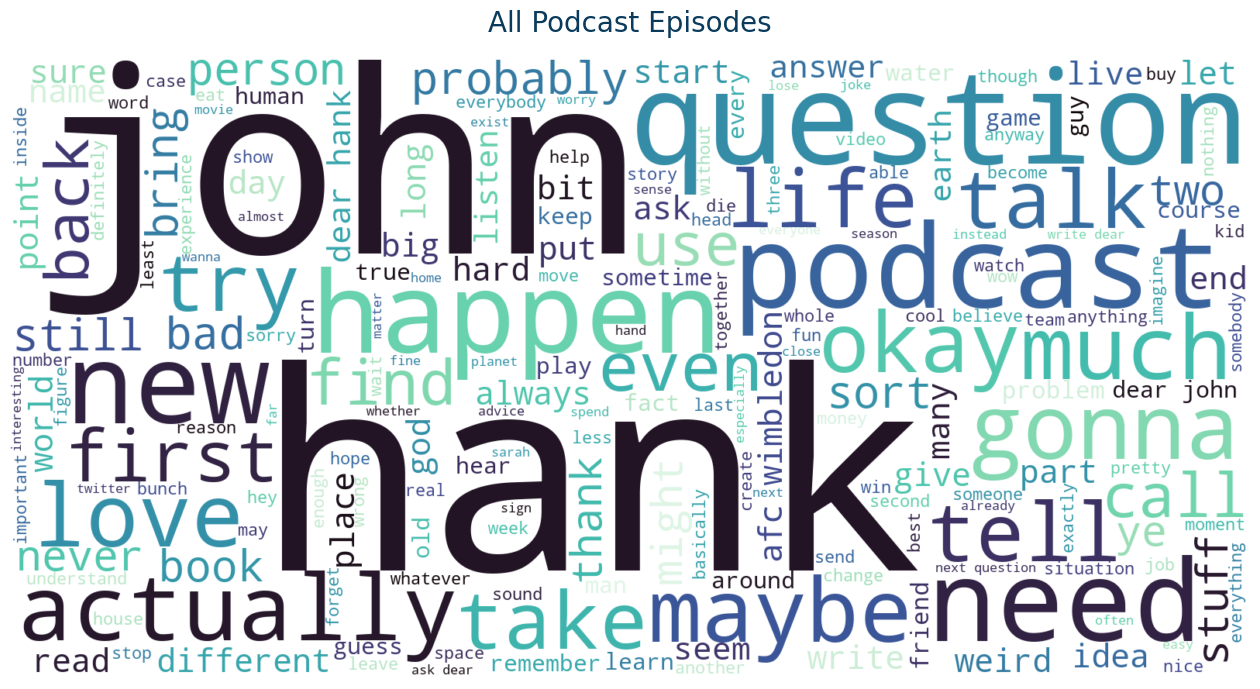

In [26]:
generate_wordcloud(all_text, stopwords, title = 'All Podcast Episodes');

In [27]:
# Re-add dhj_keywords to our stop words (remove from future word clouds)
stopwords |= dhj_keywords

#### **The following word cloud charts highlight the dominant topics and themes for a specific year-month period**

#### **September 2023**

**This month showed the highest average sentiment score.**

**It also aligns with the podcast’s return following Hank’s cancer treatment.**

,title,url,episode_date,transcript,episode_number,title_text,overall_sentiment,year,month,month_name
373,Dear Hank & John - 373: Infinitely More Versat...,https://podscripts.co/podcasts/dear-hank-john/...,2023-09-18,"Cold open. Oh my gosh, it's happening. Hello, ...",373,Infinitely More Versatile (w/ Mike Trapp!),0.258265,2023,9,September


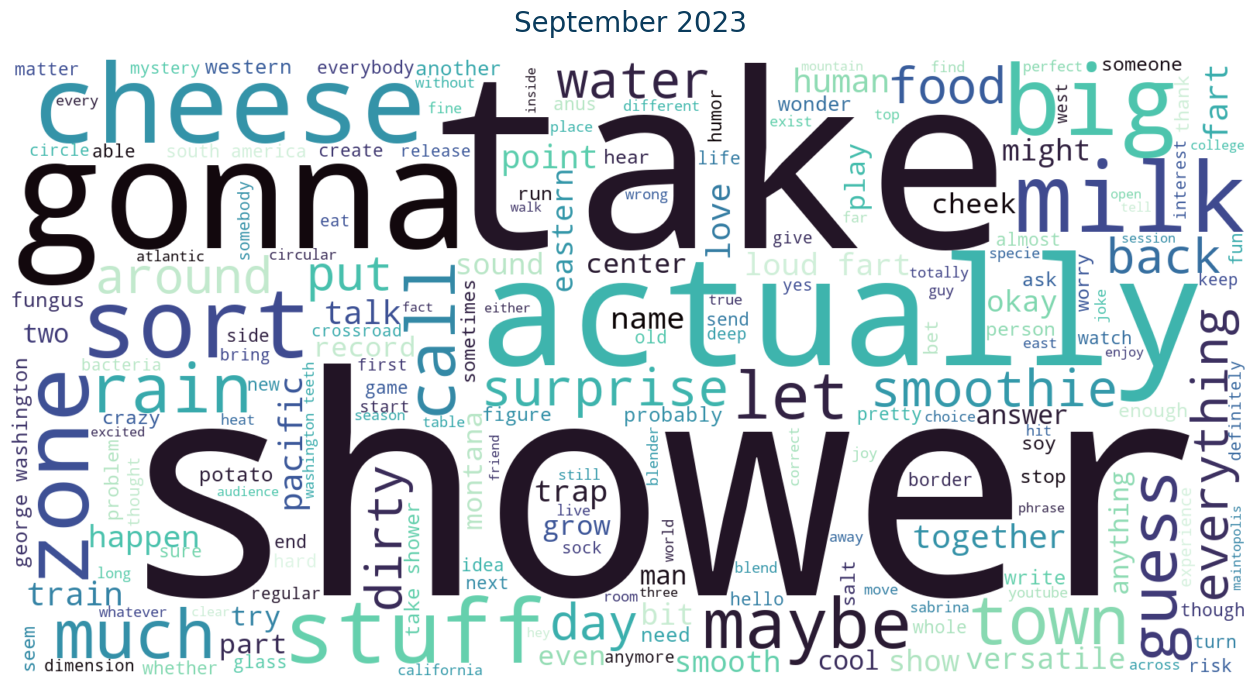

In [28]:
subset_09_2023 = df_episodes[
    (df_episodes['episode_date'].dt.year == 2023) &
    (df_episodes['episode_date'].dt.month == 9)
]

display(subset_09_2023)

subset_09_2023_text = " ".join(
    subset_09_2023['transcript'].astype(str).apply(preprocess_for_wordcloud).tolist()
)

generate_wordcloud(subset_09_2023_text, stopwords, title = 'September 2023');

#### **February 2025**
**This month showed the lowest average sentiment score.**

,title,url,episode_date,transcript,episode_number,title_text,overall_sentiment,year,month,month_name
407,Dear Hank & John - 407: Concepts of a Bubble,https://podscripts.co/podcasts/dear-hank-john/...,2025-02-19,You're listening to a Complexly Podcast.\nHell...,407,Concepts of a Bubble,0.109741,2025,2,February


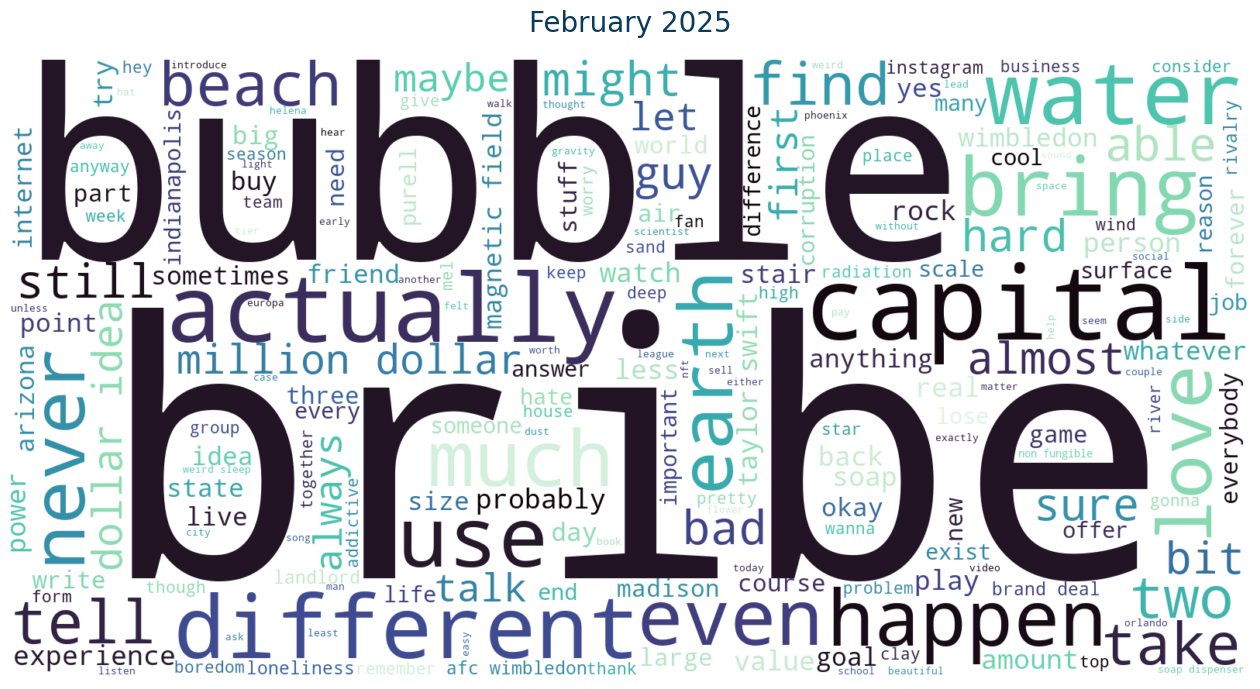

In [29]:
subset_02_2025 = df_episodes[
    (df_episodes['episode_date'].dt.year == 2025) &
    (df_episodes['episode_date'].dt.month == 2)
]

display(subset_02_2025)

subset_02_2025_text = " ".join(
    subset_02_2025['transcript'].astype(str).apply(preprocess_for_wordcloud).tolist()
)

generate_wordcloud(subset_02_2025_text, stopwords, title = 'February 2025');

#### **Most recent Podcast Month (at the time of code execution)**

**What have Hank and John been discussing recently?**


,title,url,episode_date,transcript,episode_number,title_text,overall_sentiment,year,month,month_name
443,Dear Hank & John - 443: A Top Podcast for the ...,https://podscripts.co/podcasts/dear-hank-john/...,2026-03-04,You're listening to a Complexly podcast.\nWelc...,443,A Top Podcast for the Elderly,0.172242,2026,3,March


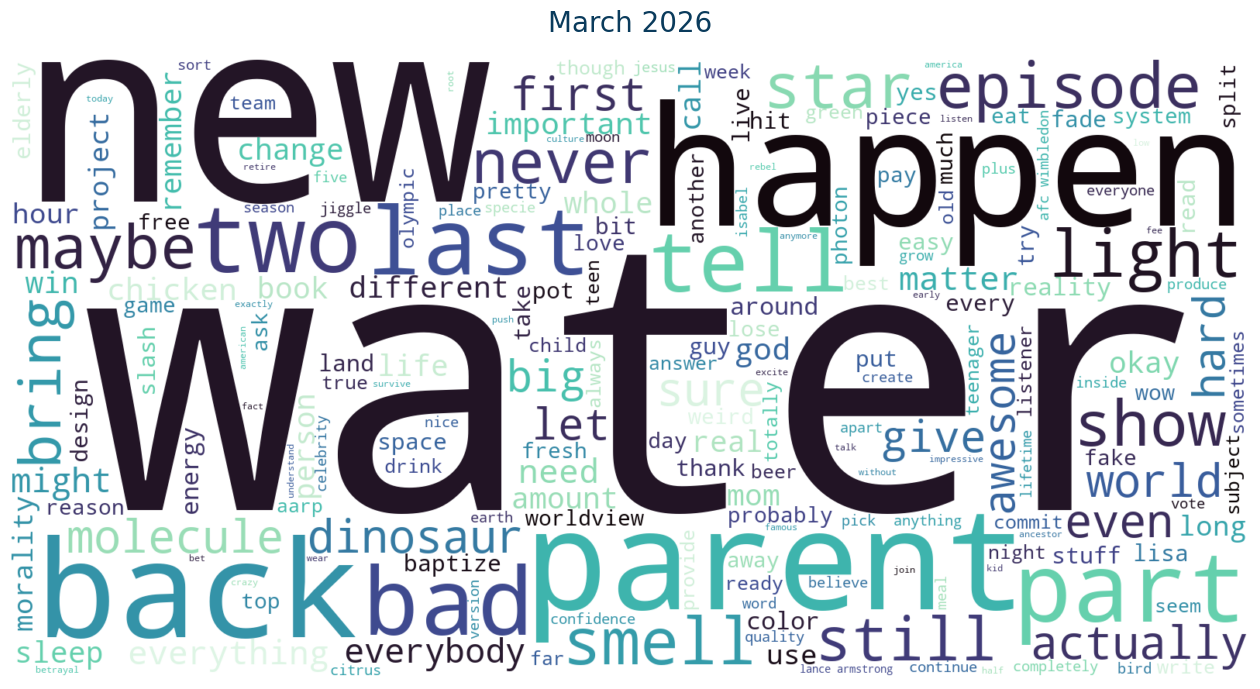

In [30]:
# Get the most recent episode_date in the dataset
most_recent_date = df_episodes['episode_date'].max()

most_recent_year  = most_recent_date.year
most_recent_month = most_recent_date.month

# Look up the month name from your existing column
most_recent_month_name = (
    df_episodes.loc[df_episodes['episode_date'] == most_recent_date, 'month_name']
    .iloc[0]
)

subset_most_recent = df_episodes[
    (df_episodes['episode_date'].dt.year == most_recent_year) &
    (df_episodes['episode_date'].dt.month == most_recent_month)
]

display(subset_most_recent)

subset_most_recent_text = " ".join(
    subset_most_recent['transcript'].astype(str).apply(preprocess_for_wordcloud).tolist()
)

generate_wordcloud(subset_most_recent_text, stopwords, title=f"{most_recent_month_name} {most_recent_year}");

---

### **TF-IDF**

TF‑IDF (Term Frequency–Inverse Document Frequency) is a statistical method used in information retrieval to measure how important a word is to a specific document (or in this case, a podcast episode) relative to the entire collection of episodes.

It helps surface the core topics of each episode by down‑weighting words that appear frequently across the whole podcast. A word cloud may highlight commonly repeated words, but TF‑IDF adjusts for this, emphasizing terms that are distinctive to a particular episode rather than globally frequent.

See more here: https://en.wikipedia.org/wiki/Tf-idf

#### **TF-IDF helper functions**

In [31]:
# Remove words or phrases from ad breaks
ad_phrase_stopwords = {
        "quince",
        "dark green",
        "factor",
        "nocd.com",
        "weather on the way",
        "mattress",
        "smalls"
        # add more here...
    }

def remove_ad_phrases(tokens, ad_phrases):
    """ Remove ad-related phrases from a token list """    
    filtered = []
    i = 0
    n = len(tokens)

    # Precompute phrase lengths
    phrase_lengths = sorted(
        {len(p.split()) for p in ad_phrases},
        reverse=True
    )

    while i < n:
        matched = False

        for L in phrase_lengths:
            if i + L <= n:
                phrase = " ".join(tokens[i:i+L])
                if phrase in ad_phrases:
                    i += L
                    matched = True
                    break

        if not matched:
            filtered.append(tokens[i])
            i += 1

    return filtered

def remove_repeated_word_bigrams(tokens):
    """ Remove repeated word bigrams found after tokenization during EDA """
    cleaned = []
    i = 0
    while i < len(tokens):
        if i + 1 < len(tokens) and tokens[i] == tokens[i+1]:
            cleaned.append(tokens[i])
            i += 2
        else:
            cleaned.append(tokens[i])
            i += 1
    return cleaned


def top_terms_for_episode(i, n=10):
    """ Extract top N terms for an episode """
    row = tfidf_matrix[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:n]
    return [(feature_names[j], row[j]) for j in top_idx]

def dedupe_ngrams(top_terms):
    """
    Remove redundant n-grams by keeping the longest meaningful phrase and discarding its component words.
    Example:
        If 'terminal velocity' appears, drop 'terminal' and 'velocity'.
    Input:
        top_terms: list of (term, score) tuples, where term is a string containing 1–3 words.
    Output:
        A filtered list of (term, score) tuples with overlaps removed.
    """
        
    cleaned = []
    used_words = set()

    # Sort by length of the term (longest phrase first)
    for term, score in sorted(top_terms, key=lambda x: (-len(x[0].split()), -len(x[0]))):
        words = term.split()
        # Only keep the phrase if none of its component words were used already
        if not any(w in used_words for w in words):
            cleaned.append((term, score))
            used_words.update(words)

    return cleaned

def bias_toward_longer_ngrams(terms, trigram_boost=1.5, bigram_boost=1.2):
    """ Bias scoring towards longer n-grams """
    biased = []
    for term, score in terms:
        length = len(term.split())
        if length == 3:
            score *= trigram_boost
        elif length == 2:
            score *= bigram_boost
        biased.append((term, score))
    return biased

def build_episode_keywords(episodes, n_raw=50, n_final=20):
    """ Build keyword summaries for each episode """

    episode_keywords = []

    for i, ep in enumerate(episodes):

        # 1. Raw TF-IDF terms
        raw_terms = top_terms_for_episode(i, n=n_raw)

        # 2. Bias toward trigrams
        biased_terms = bias_toward_longer_ngrams(raw_terms)

        # 3. Dedupe after biasing
        cleaned_terms = dedupe_ngrams(biased_terms)

        # 4. Sort by TF-IDF score after dedupe
        cleaned_terms = sorted(cleaned_terms, key=lambda x: x[1], reverse=True)

        # 5. Keep only the top N terms
        cleaned_terms = cleaned_terms[:n_final]

        # 6. Append result
        episode_keywords.append({
            "title": ep["title"],
            "episode_number": ep["episode_number"],
            "title_text": ep["title_text"],
            "episode_date": ep["episode_date"],
            "top_terms": cleaned_terms
        })

    return episode_keywords


In [32]:
def preprocess_for_tfidf(text, stopwords=None):
    """ Text preprocessing needed for TF‑IDF analysis """

    # 0) Ensure input is a string
    if not isinstance(text, str):
        return ""
    
    # 1) Basic text normalization
    text = clean_text(text)

    # 2) Sentence tokenization
    sentences = nltk.sent_tokenize(text)

    # 3) Remove repeated sentences (transcript glitches)
    sentences = dedupe_sentences(sentences, max_repeats=2)

    # 4) Remove repeated n‑grams inside each sentence (transcript glitches)
    cleaned_sentences = [
        remove_repeated_ngrams(s, max_repeats=1)
        for s in sentences
    ]

    # 5) Lemmatize each sentence
    lemmatized_sentences = [
        " ".join(
            lemmatizer.lemmatize(w, get_wordnet_pos(p))
            for w, p in nltk.pos_tag(s.split())
        )
        for s in cleaned_sentences
    ]

    # 6) Tokenize lemmatized sentences
    tokens = " ".join(lemmatized_sentences).split()
    
    # 7) Remove ad‑related phrase
    tokens = remove_ad_phrases(tokens, ad_phrase_stopwords)

    # 8) Remove stopwords
    if stopwords is not None:
        tokens = [t for t in tokens if t.lower() not in stopwords]

    # 9) Remove repeated‑word bigrams created by stopword removal
    tokens = remove_repeated_word_bigrams(tokens)

    # 10) Return a single clean string for TF-IDF analysis
    return " ".join(tokens)


In [33]:
# ---------------------------------------------------------
# Construct our corpus of documents
# ---------------------------------------------------------
corpus = [
    preprocess_for_tfidf(ep["transcript"], stopwords=stopwords)
    for ep in tqdm(episodes, desc="Building corpus")
]

Building corpus: 100%|████████████████████████| 444/444 [01:35<00:00,  4.66it/s]


In [34]:
# Create a TF-IDF vectorizer object
vectorizer = TfidfVectorizer(
    # Ignore terms that appear in fewer than 2 documents
    min_df=2,
   # Ignore terms that appear in more than 90% of documents
    max_df=0.90,
    # Extract unigrams, bigrams, and trigrams
    ngram_range=(1, 3),
)

# Fit the vectorizer to the corpus and transform it into a sparse TF‑IDF matrix
tfidf_matrix = vectorizer.fit_transform(corpus)

# Get the list of all n‑gram features 
feature_names = vectorizer.get_feature_names_out()

In [35]:
# Get top terms for each episode
episode_keywords = build_episode_keywords(episodes, n_raw=50, n_final=20)

In [36]:
# Helper function to look up top terms by episode number
episode_top_terms_lookup = {ep["episode_number"]: ep for ep in episode_keywords}

In [37]:
def plot_top_terms(episode_number, n=20):
    """ Plot the top N TF-IDF terms for a given episode """
    ep = episode_top_terms_lookup.get(episode_number)
    if ep is None:
        print(f"No episode found with number {episode_number}")
        return
    
    terms_scores = ep["top_terms"][:n]

    # Show highest scoring terms at the top of the chart
    terms = [t for t, _ in terms_scores][::-1]
    scores = [s for _, s in terms_scores][::-1]

    # Format the date for display
    date_str = ep["episode_date"].strftime("%B %d, %Y")

    
    
    plt.figure(figsize=(8, 4))
    plt.barh(terms, scores, color="steelblue")
    plt.title(
        f"Episode {episode_number}: {ep['title_text']}\n"
        f"{date_str}",
        fontsize=12
    )    
    plt.xlabel("TF-IDF Score")
    plt.tight_layout()
    plt.show()


#### **Top Terms From the Most Recent Podcast**

In [38]:
most_recent_episode_num = max(episodes, key=lambda ep: ep["episode_date"])['episode_number']

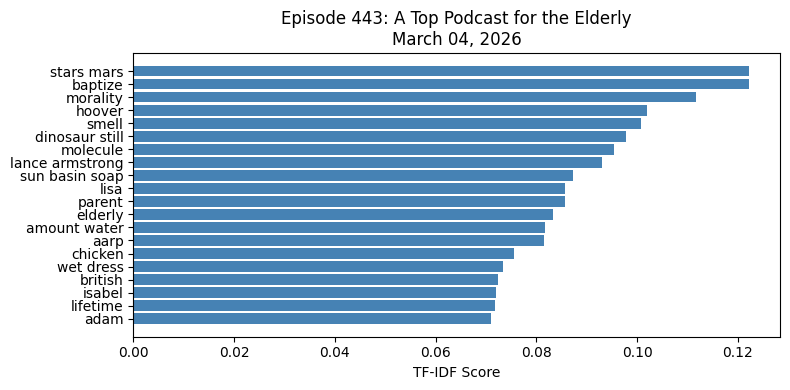

In [39]:
plot_top_terms(most_recent_episode_num)

#### **Top Terms From a Random Podcast**

In [40]:
random_episode_num = random.randint(1, most_recent_episode_num)

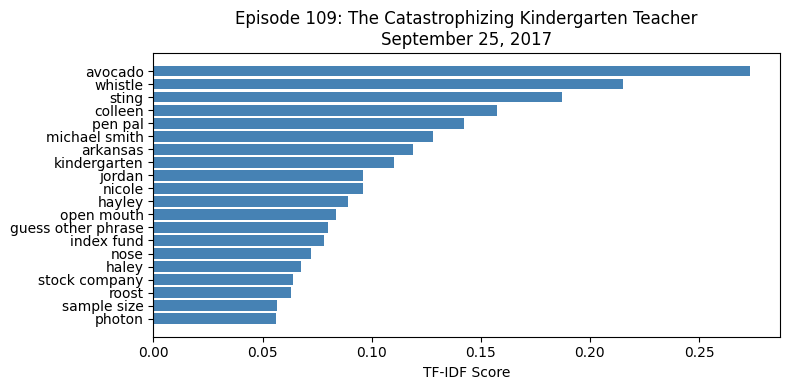

In [42]:
plot_top_terms(random_episode_num)